<a href="https://colab.research.google.com/github/Mikhailo88/MN-Praktychni-K4/blob/main/%D0%9B%D0%B0%D0%B12_1_%D0%9E%D0%BB%D1%8C%D1%85%D0%BE%D0%B2%D0%B5%D0%BD%D0%BA%D0%BE_%D0%A4%D0%86%D0%A2_4_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Ольховенко М.В. ФІТ 4-8

---



In [50]:
import numpy as np
import pandas as pd
import requests

# Завдання 1

**Був присутній на парі**

Обробка та аналіз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [51]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_1602/670621700.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


2.	Визначити розмір датасета.

In [53]:
print("Розмір датасета:", df.shape)

Розмір датасета: (222, 4)


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [54]:
df.columns = [
    "Країна",
    "ВВП_МВФ_2026",
    "ВВП_Світовий_банк_2025",
    "ВВП_ООН_2024"
]

print(df.head())

          Країна ВВП_МВФ_2026 ВВП_Світовий_банк_2025 ВВП_ООН_2024
0          World    126295331              118350166    111565144
1  United States     32383920               30769700     29298000
2     China[n 1]     20851593               19498039     18743802
3        Germany      5452858                5050923      4659929
4          Japan      4379253                4435163      4026211


In [55]:
df = df[df["Країна"] != "World"]

4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [56]:
df.isnull().sum()

,0
Країна,0
ВВП_МВФ_2026,0
ВВП_Світовий_банк_2025,0
ВВП_ООН_2024,0


In [57]:
df["ВВП_МВФ_2026"] = pd.to_numeric(df["ВВП_МВФ_2026"], errors="coerce")
df["ВВП_Світовий_банк_2025"] = pd.to_numeric(df["ВВП_Світовий_банк_2025"], errors="coerce")
df["ВВП_ООН_2024"] = pd.to_numeric(df["ВВП_ООН_2024"], errors="coerce")

/tmp/ipykernel_1602/1400213437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ВВП_МВФ_2026"] = pd.to_numeric(df["ВВП_МВФ_2026"], errors="coerce")
/tmp/ipykernel_1602/1400213437.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ВВП_Світовий_банк_2025"] = pd.to_numeric(df["ВВП_Світовий_банк_2025"], errors="coerce")
/tmp/ipykernel_1602/1400213437.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

In [58]:
df.dtypes

,0
Країна,object
ВВП_МВФ_2026,float64
ВВП_Світовий_банк_2025,float64
ВВП_ООН_2024,float64


In [59]:
df

,Країна,ВВП_МВФ_2026,ВВП_Світовий_банк_2025,ВВП_ООН_2024
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [60]:
df.isnull().sum()

,0
Країна,0
ВВП_МВФ_2026,31
ВВП_Світовий_банк_2025,35
ВВП_ООН_2024,9


In [61]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: x.fillna(x.mean()), axis=1)

df.isnull().sum()

,0
Країна,0
ВВП_МВФ_2026,8
ВВП_Світовий_банк_2025,8
ВВП_ООН_2024,8


5. Ще раз вивести датасет

In [62]:
df.head()

,Країна,ВВП_МВФ_2026,ВВП_Світовий_банк_2025,ВВП_ООН_2024
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [63]:
df = df.drop_duplicates()

print("Дублікатів після видалення:", df.duplicated().sum())

Дублікатів після видалення: 0


7.	Вивести описову статистику датасету describe()

In [64]:
df.describe()

,ВВП_МВФ_2026,ВВП_Світовий_банк_2025,ВВП_ООН_2024
count,2.130000e+02,2.130000e+02,2.130000e+02
mean,5.943385e+05,5.561409e+05,5.246237e+05
std,2.723652e+06,2.575206e+06,2.455329e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,8.549000e+03,8.840000e+03,8.549000e+03
50%,4.380000e+04,3.960100e+04,3.709400e+04
75%,2.786360e+05,2.640570e+05,2.571450e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [65]:
df["Різниця_МВФ_СБ"] = abs(df["ВВП_МВФ_2026"] - df["ВВП_Світовий_банк_2025"])

# Знаходимо найбільшу різницю між даними МВФ та Світового банку
max_diff = df["Різниця_МВФ_СБ"].max()

country = df.loc[df["Різниця_МВФ_СБ"] == max_diff]["Країна"].values[0]
print(f"{country} має найбільшу різницю між ВВП МВФ та Світового банку: {max_diff}")

df.head(10)

United States має найбільшу різницю між ВВП МВФ та Світового банку: 1614220.0


,Країна,ВВП_МВФ_2026,ВВП_Світовий_банк_2025,ВВП_ООН_2024,Різниця_МВФ_СБ
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [67]:
correlation = df[
    ["ВВП_МВФ_2026", "ВВП_Світовий_банк_2025", "ВВП_ООН_2024"]
].corr()

print("Матриця кореляції:")
print(correlation)

# Отримуємо кореляцію між кожною парою показників
pairs = {
    "МВФ – Світовий банк":
        correlation.loc["ВВП_МВФ_2026", "ВВП_Світовий_банк_2025"],

    "МВФ – ООН":
        correlation.loc["ВВП_МВФ_2026", "ВВП_ООН_2024"],

    "Світовий банк – ООН":
        correlation.loc["ВВП_Світовий_банк_2025", "ВВП_ООН_2024"]
}

print("\nКореляція між парами:")
for pair, value in pairs.items():
    print(f"{pair}: {value:.4f}")

# Знаходимо пару з найвищою кореляцією
max_pair = max(pairs, key=pairs.get)

print(f"\nНайвища кореляція: {max_pair} = {pairs[max_pair]:.4f}")

Матриця кореляції:
                        ВВП_МВФ_2026  ВВП_Світовий_банк_2025  ВВП_ООН_2024
ВВП_МВФ_2026                1.000000                0.999877      0.999816
ВВП_Світовий_банк_2025      0.999877                1.000000      0.999860
ВВП_ООН_2024                0.999816                0.999860      1.000000

Кореляція між парами:
МВФ – Світовий банк: 0.9999
МВФ – ООН: 0.9998
Світовий банк – ООН: 0.9999

Найвища кореляція: МВФ – Світовий банк = 0.9999


Обчислити середнє значення за стовпцями

In [68]:
# Обчислення середнього значення ВВП МВФ
mean_IMF = df["ВВП_МВФ_2026"].mean()
print("Середнє значення ВВП МВФ:", np.float64(mean_IMF))

Середнє значення ВВП МВФ: 594338.5211267605


In [69]:
# Обчислення середнього значення ВВП Світового банку
mean_WB = df["ВВП_Світовий_банк_2025"].mean()
print("Середнє значення ВВП Світового банку:", np.float64(mean_WB))

Середнє значення ВВП Світового банку: 556140.9014084507


In [70]:
# Обчислення середнього значення ВВП ООН
mean_UN = df["ВВП_ООН_2024"].mean()
print("Середнє значення ВВП ООН:", np.float64(mean_UN))

Середнє значення ВВП ООН: 524623.7323943662


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [71]:
df["Стандартне_відхилення"] = df[["ВВП_МВФ_2026", "ВВП_Світовий_банк_2025", "ВВП_ООН_2024"]].std(axis=1)

# Знаходимо країну з найвищою варіативністю
max_std = df["Стандартне_відхилення"].max()

country_max_std = df.loc[df["Стандартне_відхилення"] == max_std,"Країна"].values[0]

print("Країна з найвищою варіативністю:", country_max_std)
print("Стандартне відхилення:", max_std)

# Виводимо перші 10 країн
print(df[["Країна", "Стандартне_відхилення"]].head(10))

Країна з найвищою варіативністю: United States
Стандартне відхилення: 1543508.4140144275
            Країна  Стандартне_відхилення
1    United States           1.543508e+06
2       China[n 1]           1.068002e+06
3          Germany           3.964771e+05
4            Japan           2.217380e+05
5   United Kingdom           2.898838e+05
6            India           1.149291e+05
7           France           2.179348e+05
8            Italy           1.787283e+05
9           Russia           2.558938e+05
10          Brazil           2.374046e+05


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [73]:
max_IMF = df["ВВП_МВФ_2026"].idxmax()
min_IMF = df["ВВП_МВФ_2026"].idxmin()

max_WB = df["ВВП_Світовий_банк_2025"].idxmax()
min_WB = df["ВВП_Світовий_банк_2025"].idxmin()

max_UN = df["ВВП_ООН_2024"].idxmax()
min_UN = df["ВВП_ООН_2024"].idxmin()

print("IMF (2026):")
print("Найвищий показник:", df.loc[max_IMF, "Країна"],"-", df.loc[max_IMF, "ВВП_МВФ_2026"])
print("Найнижчий показник:", df.loc[min_IMF, "Країна"],"-", df.loc[min_IMF, "ВВП_МВФ_2026"])

print("\nWorld Bank (2025):")
print("Найвищий показник:", df.loc[max_WB, "Країна"],"-", df.loc[max_WB, "ВВП_Світовий_банк_2025"])
print("Найнижчий показник:", df.loc[min_WB, "Країна"],"-", df.loc[min_WB, "ВВП_Світовий_банк_2025"])

print("\nUnited Nations (2024):")
print("Найвищий показник:", df.loc[max_UN, "Країна"],"-", df.loc[max_UN, "ВВП_ООН_2024"])
print("Найнижчий показник:", df.loc[min_UN, "Країна"],"-", df.loc[min_UN, "ВВП_ООН_2024"])

IMF (2026):
Найвищий показник: United States - 32383920.0
Найнижчий показник: Tuvalu - 65.0

World Bank (2025):
Найвищий показник: United States - 30769700.0
Найнижчий показник: Tuvalu - 57.0

United Nations (2024):
Найвищий показник: United States - 29298000.0
Найнижчий показник: Tuvalu - 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

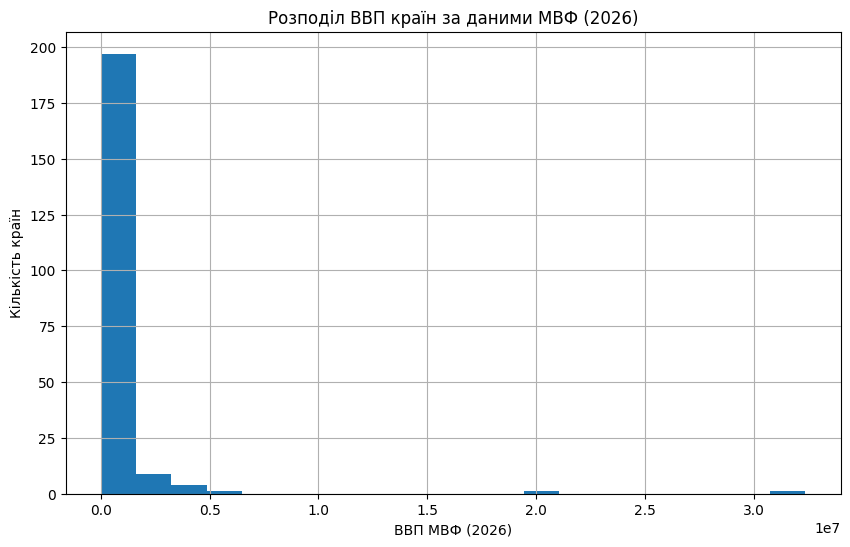

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["ВВП_МВФ_2026"], bins=20)

plt.xlabel("ВВП МВФ (2026)")
plt.ylabel("Кількість країн")
plt.title("Розподіл ВВП країн за даними МВФ (2026)")
plt.grid(True)

plt.show()

Більшість країн мають відносно невеликі значення ВВП, тоді як декілька країн мають значно вищі показники та виділяються на загальному фоні. Це свідчить про значну нерівномірність розподілу ВВП між країнами.

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [77]:
# Загальні значення ВВП за кожним джерелом
total_IMF = df["ВВП_МВФ_2026"].sum()
total_WB = df["ВВП_Світовий_банк_2025"].sum()
total_UN = df["ВВП_ООН_2024"].sum()

# Розрахунок частки кожної країни
df["Частка_МВФ_2026"] = (df["ВВП_МВФ_2026"] / total_IMF * 100)

df["Частка_Світовий_банк_2025"] = (df["ВВП_Світовий_банк_2025"] / total_WB * 100)

df["Частка_ООН_2024"] = (df["ВВП_ООН_2024"] / total_UN * 100)

# Виведення результату
print("Частки країн у загальному ВВП:")

print(df[["Країна", "Частка_МВФ_2026", "Частка_Світовий_банк_2025", "Частка_ООН_2024"]].head(20).to_string(index=False))

Частки країн у загальному ВВП:
        Країна  Частка_МВФ_2026  Частка_Світовий_банк_2025  Частка_ООН_2024
 United States        25.580907                  25.975195        26.218657
    China[n 1]        16.471220                  16.459874        16.773749
       Germany         4.307355                   4.263893         4.170151
         Japan         3.459287                   3.744080         3.603039
United Kingdom         3.368873                   3.378909         3.298479
         India         3.280714                   3.339636         3.536847
        France         2.840649                   2.841780         2.828267
         Italy         2.162947                   2.153976         2.130590
        Russia         2.098401                   2.162209         1.944954
        Brazil         2.082176                   1.924665         1.956083
        Canada         1.980614                   1.958415         2.031481
     Australia         1.677774                   1.51827

Частки країн у загальному значенні ВВП відрізняються залежно від року та джерела даних. Найбільшу частку мають країни з найбільшим обсягом ВВП, тоді як частки більшості країн є значно меншими. Зміни часток між 2024, 2025 та 2026 роками свідчать про зміну співвідношення економічних показників країн у світовій економіці.

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [82]:
top10 = df.sort_values("ВВП_МВФ_2026", ascending=False).head(10)

print("Топ-10 країн:")
print(top10[
    [
        "Країна",
        "ВВП_ООН_2024",
        "ВВП_Світовий_банк_2025",
        "ВВП_МВФ_2026"
    ]
].to_string(index=False))

Топ-10 країн:
        Країна  ВВП_ООН_2024  ВВП_Світовий_банк_2025  ВВП_МВФ_2026
 United States    29298000.0              30769700.0    32383920.0
    China[n 1]    18743802.0              19498039.0    20851593.0
       Germany     4659929.0               5050923.0     5452858.0
         Japan     4026211.0               4435163.0     4379253.0
United Kingdom     3685881.0               4002588.0     4264794.0
         India     3952244.0               3956067.0     4153191.0
        France     3160443.0               3366316.0     3596094.0
         Italy     2380825.0               2551557.0     2738164.0
        Russia     2173386.0               2561310.0     2656452.0
        Brazil     2185822.0               2279920.0     2635912.0


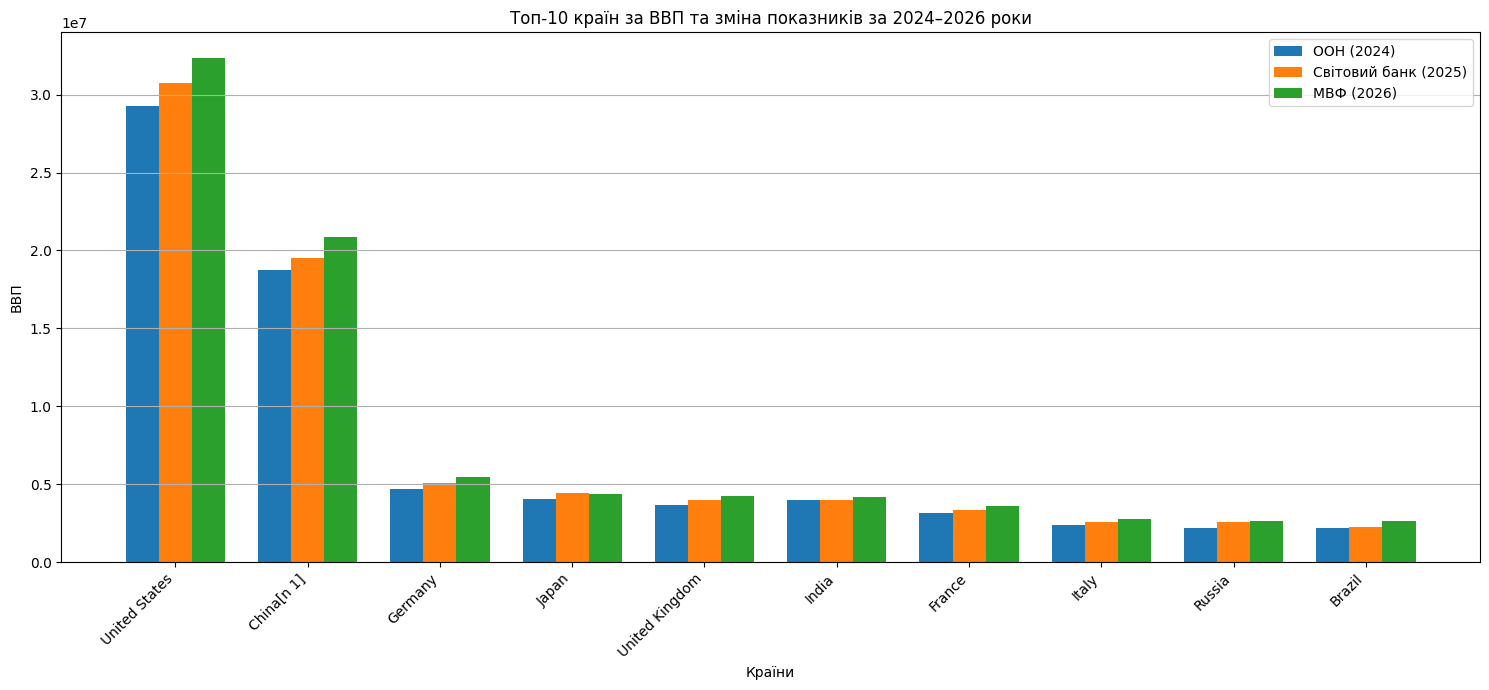

In [83]:
countries = top10["Країна"]

x = np.arange(len(countries))
width = 0.25

plt.figure(figsize=(15, 7))

plt.bar(
    x - width,
    top10["ВВП_ООН_2024"],
    width,
    label="ООН (2024)"
)

plt.bar(
    x,
    top10["ВВП_Світовий_банк_2025"],
    width,
    label="Світовий банк (2025)"
)

plt.bar(
    x + width,
    top10["ВВП_МВФ_2026"],
    width,
    label="МВФ (2026)"
)

plt.xlabel("Країни")
plt.ylabel("ВВП")
plt.title("Топ-10 країн за ВВП та зміна показників за 2024–2026 роки")

plt.xticks(
    x,
    countries,
    rotation=45,
    ha="right"
)

plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Для аналізу було обрано топ-10 країн за показником ВВП МВФ за 2026 рік. На гістограмі порівняно показники ВВП за даними ООН за 2024 рік, Світового банку за 2025 рік та МВФ за 2026 рік. За отриманими даними можна визначити країни, для яких показник послідовно зростає або зменшується протягом досліджуваного періоду.